# CS235 Spring 2026 Course Project

## Name: Kevin Bach

## SID: 862194701

# Introduction Method Project Pt.1

In this project, a number of data mining techniques that we cover in this class will be implemented and applied to a real-world imbalanced dataset.

Dataset: Wisconsin Breast Cancer Diagnostic dataset from the UCI data repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

# Setup

Create new python environment for the project

Install the required packages

In [21]:
!pip install ucimlrepo

  Obtaining dependency information for ucimlrepo from https://files.pythonhosted.org/packages/3b/07/1252560194df2b4fad1cb3c46081b948331c63eb1bb0b97620d508d12a53/ucimlrepo-0.0.7-py3-none-any.whl.metadata


# Library Imports

In [2]:
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Manipulation Libraries
import itertools, collections
import numpy as np
import pandas as pd

# Getting UCI Repo (Googled how to read repo files)
from ucimlrepo import fetch_ucirepo

# Imputation, Metric Mesurements Libraries
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# Loaing in the Dataset

In [3]:
# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data into dataframe
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Metadata
print(breast_cancer_wisconsin_diagnostic.metadata)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

# Exploration Data Analysis

In [4]:
# Printing the feature columns
print("The Features Columns:")
X

The Features Columns:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
# Print the feature shape
print("Features Shape:", X.shape) # outputed 569 Rows, 30 columns

# Print the feature Statistic Information
print("\nFeature Statistic Information:")
X.describe()

Features Shape: (569, 30)

Feature Statistic Information:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
# print feature data types
print("Feature columns Datatype:")
X.info()

Feature columns Datatype:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-nul

# Diagnosis Classes
 
 - B represents "Benign"
 - M represents "Malignant"

In [7]:
# Printing the target column
print("The Target Column:")
y

The Target Column:


,Diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [8]:
# Printing the target column Datatype
print("The Target Datatype:")
y.info()

The Target Datatype:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Diagnosis  569 non-null    object
dtypes: object(1)
memory usage: 4.6+ KB


# Q1 Data cleaning & missing value prediction 

 
### Objective
The goal of Part 1 is to explore different aspects of data preprocessing, including missing value prediction, dimensionality reduction and observing their impact on a downstream classification task. We use Logistic Regression as our model and evaluate performance using the F1 Score across stratified 5-fold cross-validation.

### Scope of Part 1
1.  **Data Cleaning & Imputation:** We will manually introduce missing values (NaNs) into the dataset under two scenarios:
    * **Single Feature Noise:** For p% of all the data points, replace the value of the first feature (‘radius’) with ‘nan’. 


    * **Random Feature Noise:** For p% of all the data points, select a feature uniformly at random and replace its value with ‘nan’ 
    
    * Compare Imputations: **SimpleImputer** and **IterativeImputer** for the two noisy variants of the data.
    * **Performance Measure**: getting the average +/- standard deviation of the F1 score calculated using stratified 5-fold cross-validation
    
    * **Plot**: For p = [20%, 40%], produce a figure for each value of p that compares the performance of logistic regression on the two noisy variants of our dataset before and after imputation, for both types of imputation
 
    
    
2.  **Dimensionality Reduction:** We will evaluate the trade-offs of reducing feature space using:
    * **Singular Value Decomposition (SVD)** via NumPy.
    * **Autoencoders** (Neural Networks) implemented with Scikit-learn.
    * **plot:** for k = [2, 5, 10] being the dimensionality of the latent representation, create a figure that shows the performance as a function of k for the two dimensionality reduction techniques and draws as a straight horizontal line the average performance without dimensionality reduction. You may skip adding error-bars on that horizontal line only. 
    

# Q1 Single Feature Noise

- Adding **NaN Values** to the first feature radius which will be **Radius1** column in the WDBC dataset.

- We will first copy the original dataset for each of the percentage noises (20% & 40%) so that we dont acidentally make changes to the orignial dataset

In [9]:
"""
 Create copies of the original features to avoid 
 modifying the original dataset for each percentage
 p = [20% , 40%]
"""
single_feature_20 = X.copy()
single_feature_40 = X.copy()

# Set a random seed for results stay consistent
np.random.seed(42)

# 20% Noise Level
# Calculate the number of samples to change to NaN in the radius1 column
num_samples_20 = int(0.20 * len(X)) # 20% of 569 which is 113

# Randomly select 20% indices from the dataframe to be turned into NaNs
indices_20 = np.random.choice(X.index, num_samples_20, replace=False)

# Using .loc to replace the 'radius1' values
# radius1 is the first feature in the dataset
single_feature_20.loc[indices_20, 'radius1'] = np.nan

# 40% Noise Level
# Calculate the number of samples to change to NaN in the radius1 column
num_samples_40 = int(0.40 * len(X)) # 40% of 569 which is 227

# Randomly select 40% indices from the dataframe to be turned into NaNs
indices_40 = np.random.choice(X.index, num_samples_40, replace=False)

# Replace 'radius1' values with NaN for the 40% noise
single_feature_40.loc[indices_40, 'radius1'] = np.nan

# Print the count of missing values
print(f"Total NaNs with 20% of the data points, replaced on the first radius feature (radius1) column: {single_feature_20['radius1'].isnull().sum()}")
print(f"Total NaNs with 40% of the data points, replaced on the first radius feature (radius1) column: {single_feature_40['radius1'].isnull().sum()}")

Total NaNs with 20% of the data points, replaced on the first radius feature (radius1) column: 113
Total NaNs with 40% of the data points, replaced on the first radius feature (radius1) column: 227


In [10]:
# Checking if the Radius1 column got NaN (Null values)
print("Showing the 20% NaN values in the first radius feature (Radius1):")
single_feature_20.isnull().sum()

Showing the 20% NaN values in the first radius feature (Radius1):


radius1               113
texture1                0
perimeter1              0
area1                   0
smoothness1             0
compactness1            0
concavity1              0
concave_points1         0
symmetry1               0
fractal_dimension1      0
radius2                 0
texture2                0
perimeter2              0
area2                   0
smoothness2             0
compactness2            0
concavity2              0
concave_points2         0
symmetry2               0
fractal_dimension2      0
radius3                 0
texture3                0
perimeter3              0
area3                   0
smoothness3             0
compactness3            0
concavity3              0
concave_points3         0
symmetry3               0
fractal_dimension3      0
dtype: int64

In [11]:
# Checking if the Radius1 column got NaN (Null values)
print("Showing the 40% NaN values in the first radius feature (Radius1):")
single_feature_40.isnull().sum()

Showing the 40% NaN values in the first radius feature (Radius1):


radius1               227
texture1                0
perimeter1              0
area1                   0
smoothness1             0
compactness1            0
concavity1              0
concave_points1         0
symmetry1               0
fractal_dimension1      0
radius2                 0
texture2                0
perimeter2              0
area2                   0
smoothness2             0
compactness2            0
concavity2              0
concave_points2         0
symmetry2               0
fractal_dimension2      0
radius3                 0
texture3                0
perimeter3              0
area3                   0
smoothness3             0
compactness3            0
concavity3              0
concave_points3         0
symmetry3               0
fractal_dimension3      0
dtype: int64

# Q1 Random Feature Noise
- Select a feature uniformly at random and replace its value with ‘nan’
- We will first copy the original dataset for each of the percentage noises (20% & 40%) so that we dont acidentally make changes to the orignial dataset

In [12]:
"""
 Create copies of the original features to avoid 
 modifying the original dataset for each percentage
 p = [20% , 40%]
"""
random_feature_20 = X.copy()
random_feature_40 = X.copy()

# 20% Random Feature Noise
# Randomly select 20% of noise to the dataset setting to NaNs
rows_to_noise_20 = np.random.choice(X.index, int(0.20 * len(X)), replace=False)

# Loop through each selected row and pick a random column to change to NaNs
for row in rows_to_noise_20:
    # Pick a random column name from the list of all features
    random_col = np.random.choice(X.columns)
    # Set that specific cell to NaN
    random_feature_20.at[row, random_col] = np.nan

# 40% Random Feature Noise
# Randomly select 40% of noise to the dataset setting to NaNs
rows_to_noise_40 = np.random.choice(X.index, int(0.40 * len(X)), replace=False)

# Loop through each selected row for the 40% variant
for row in rows_to_noise_40:
    # Pick a random column name
    random_col = np.random.choice(X.columns)
    # Set that specific cell to NaN
    random_feature_40.at[row, random_col] = np.nan

# Verification: Check total NaNs across the entire dataframe
print(f"Total NaNs with 20% of the data points, replaced on the random features: {random_feature_20.isnull().sum().sum()}")
print(f"Total NaNs with 40% of the data points, replaced on the random features: {random_feature_40.isnull().sum().sum()}")

Total NaNs with 20% of the data points, replaced on the random features: 113
Total NaNs with 40% of the data points, replaced on the random features: 227


In [13]:
# Checking if random columns got NaN (Null values)
print(random_feature_20.isnull().sum())
print("Total NaN for all the columns: ",random_feature_20.isnull().sum().sum())

radius1                3
texture1               4
perimeter1             6
area1                  2
smoothness1            2
compactness1           3
concavity1             3
concave_points1        2
symmetry1              1
fractal_dimension1     1
radius2                4
texture2               6
perimeter2             1
area2                  5
smoothness2            9
compactness2           2
concavity2             5
concave_points2        4
symmetry2              2
fractal_dimension2     5
radius3                3
texture3               4
perimeter3             2
area3                  4
smoothness3            3
compactness3           5
concavity3             7
concave_points3        4
symmetry3             10
fractal_dimension3     1
dtype: int64
Total NaN for all the columns:  113


In [14]:
# Checking if random columns got NaN (Null values)
print(random_feature_40.isnull().sum())
print("Total NaN for all the columns: ",random_feature_40.isnull().sum().sum())

radius1                7
texture1              12
perimeter1            11
area1                 10
smoothness1            8
compactness1           9
concavity1             9
concave_points1        3
symmetry1              7
fractal_dimension1     6
radius2                5
texture2               3
perimeter2             8
area2                 10
smoothness2            6
compactness2           5
concavity2             4
concave_points2       11
symmetry2              5
fractal_dimension2    12
radius3               13
texture3               8
perimeter3             8
area3                  3
smoothness3            6
compactness3           4
concavity3             4
concave_points3       11
symmetry3              9
fractal_dimension3    10
dtype: int64
Total NaN for all the columns:  227


# Q1 Imputations and Performance

 - We are going to use the ‘impute’ function of Scikit-learn: https://scikit-learn.org/1.5/modules/impute.html
 
 - Using **SimpleImputer vs IterativeImputer** 
 
 - Apply imputation to train and test sets independently.

 - Use Stratified 5-Fold Cross-Validation.

 - Calculate the F1 Score (average +/- standard deviation).

 - Compare 3 cases: Original noisy dataset, SimpleImputer, and IterativeImputer. 
 
 ### Implementation Process for both Single Feature & Random Feature (20%, 40%) :
 - **Handling NaNs:** LogisticRegression cannot handle NaN values, the "Noisy Original" was established by filling missing values with 0 using .fillna(0).
- **Imputation Strategy:** We compared **SimpleImputer** which uses the mean of the column vs **IterativeImputer** which treats the missing feature as a target and predicts it using the other 29 features.
- **Validation:** Ensure results were robust, we utilized Stratified 5-Fold Cross-Validations
- **Performance**  Measure the average +/- standard deviation of the F1 score

# Q1 Single Feature Noise Imputations for 20% Noise

In [50]:
# Showing the Dataset with the NaNs to the first Radius 'Radius1' feature (20%)
single_feature_20

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,NaN,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,NaN,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,NaN,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,NaN,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [48]:
# # Create a arrays to store F1 scores for each fold
# single_20_results = {
#     'singleNoisy_20': [],
#     'singleSimpleImputer_20': [],
#     'singleIterativeImputer_20': []
# }

# # Initialize Stratified 5-Fold CV
# cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state= 42)

# print("Single Feature Noise 20% 5-Fold Results: ")

# # Tracking each fold for each case for outputing it 
# for fold_idx, (train_idx, test_idx) in enumerate(cross_val.split(single_feature_20, y), 1):
#     # Splitting the training data and testing data
#     X_train, X_test = single_feature_20.iloc[train_idx], single_feature_20.iloc[test_idx]
#     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
#     # convert into 1D
#     y_train_flat = y_train.values.flatten()

#     # Noisy Original
#     # Logistic Regression can't work with NaN so I use .fillna(0) 
#     # Default max_iter=100 had convergence error
#     clf_noisy = LogisticRegression(max_iter=100)
#     clf_noisy.fit(X_train.fillna(0), y_train_flat)
    
#     # storing the f1 score that it predicts
#     f1_noisy = f1_score(y_test, clf_noisy.predict(X_test.fillna(0)), pos_label='M')
    
#     # Add results to the singleNoisy_20 array
#     single_20_results['singleNoisy_20'].append(f1_noisy)

#     # SimpleImputer
#     simple_imp = SimpleImputer() # default parameters
    
#     # fit transform train and test seperately
#     X_train_simple = simple_imp.fit_transform(X_train)
#     X_test_simple = simple_imp.transform(X_test)
    
#     # Default max_iter=100 had convergence error
#     clf_simple = LogisticRegression(max_iter=100)
#     # convert into 1D
#     clf_simple.fit(X_train_simple, y_train_flat)
    
#     # storing the f1 score that it predicts
#     f1_simple = f1_score(y_test, clf_simple.predict(X_test_simple), pos_label='M')
    
#     # Add results to the singleSimpleImputer_20 array
#     single_20_results['singleSimpleImputer_20'].append(f1_simple)

#     # IterativeImputer
#     # used random state = 42 for consistent and same output each run
#     iter_imp = IterativeImputer(random_state= 42)
#     X_train_iter = iter_imp.fit_transform(X_train)
#     X_test_iter = iter_imp.transform(X_test)
    
#     # Default max_iter=100 had convergence error
#     clf_iter = LogisticRegression(max_iter=100)
#     # convert into 1D
#     clf_iter.fit(X_train_iter, y_train_flat)
    
#     # storing the f1 score that it predicts
#     f1_iter = f1_score(y_test, clf_iter.predict(X_test_iter), pos_label='M')
    
#     # Add results to the singleIterativeImputer_20 array
#     single_20_results['singleIterativeImputer_20'].append(f1_iter)
    
#     # Output the F1 scores for the current fold
#     print(f"Fold {fold_idx}: Noisy={f1_noisy:.4f}, Simple={f1_simple:.4f}, Iterative={f1_iter:.4f}")

# print("\nPerformance Metrics (Average +/- standard deviation):")

# # Calculate and printing the average of f1 scores and standard deviation
# for method, scores in single_20_results.items():
#     mean_f1 = np.mean(scores)
#     std_f1 = np.std(scores)
#     print(f"{method}: Average F1 Score = {mean_f1:.4f} & Standard Deviation = +/- {std_f1:.4f}")

In [51]:
from sklearn.preprocessing import StandardScaler

# Create a arrays to store F1 scores for each fold
single_20_results = {
    'singleNoisy_20': [],
    'singleSimpleImputer_20': [],
    'singleIterativeImputer_20': []
}

# Initialize Stratified 5-Fold CV
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

print("Single Feature Noise 20% 5-Fold Results: ")

# Tracking each fold for each case for outputing it
for fold_idx, (train_idx, test_idx) in enumerate(cross_val.split(single_feature_20, y), 1):
    # Splitting the training data and testing data
    X_train, X_test = single_feature_20.iloc[train_idx], single_feature_20.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # convert into 1D
    y_train_flat = y_train.values.flatten()

    # Noisy Original
    # Logistic Regression can't work with NaN so I use .fillna(0)
    X_train_zero = X_train.fillna(0)
    X_test_zero = X_test.fillna(0)
    
    # Scaling the filled data
    X_train_scaled = scaler.fit_transform(X_train_zero)
    X_test_scaled = scaler.transform(X_test_zero)
    
    # Default max_iter=100
    clf_noisy = LogisticRegression(max_iter=100) 
    clf_noisy.fit(X_train_scaled, y_train_flat)
    # storing the f1 score that it predicts
    f1_noisy = f1_score(y_test, clf_noisy.predict(X_test_scaled), pos_label='M')
    # Add results to the singleNoisy_20 array
    single_20_results['singleNoisy_20'].append(f1_noisy)

    # SimpleImputer
    simple_imp = SimpleImputer() # default parameters
    # fit transform train and test seperately
    X_train_simple = simple_imp.fit_transform(X_train)
    X_test_simple = simple_imp.transform(X_test)
    
    # Scaling after imputation
    X_train_simple_scaled = scaler.fit_transform(X_train_simple)
    X_test_simple_scaled = scaler.transform(X_test_simple)
    
    # Default max_iter=100 
    clf_simple = LogisticRegression(max_iter=100)
    # convert into 1D
    clf_simple.fit(X_train_simple_scaled, y_train_flat)
    # storing the f1 score that it predicts
    f1_simple = f1_score(y_test, clf_simple.predict(X_test_simple_scaled), pos_label='M')
    # Add results to the singleSimpleImputer_20 array
    single_20_results['singleSimpleImputer_20'].append(f1_simple)

    # IterativeImputer
    # used random state = 42 for consistent and same output each run
    iter_imp = IterativeImputer(random_state=42)
    X_train_iter = iter_imp.fit_transform(X_train)
    X_test_iter = iter_imp.transform(X_test)
    
    # Scaling after imputation
    X_train_iter_scaled = scaler.fit_transform(X_train_iter)
    X_test_iter_scaled = scaler.transform(X_test_iter)
    
    # Default max_iter=100 
    clf_iter = LogisticRegression(max_iter=100)
    # convert into 1D
    clf_iter.fit(X_train_iter_scaled, y_train_flat)
    # storing the f1 score that it predicts
    f1_iter = f1_score(y_test, clf_iter.predict(X_test_iter_scaled), pos_label='M')
    # Add results to the singleIterativeImputer_20 array
    single_20_results['singleIterativeImputer_20'].append(f1_iter)
    
    # Output the F1 scores for the current fold
    print(f"Fold {fold_idx}: Noisy={f1_noisy:.4f}, Simple={f1_simple:.4f}, Iterative={f1_iter:.4f}")

print("\nPerformance Metrics (Average +/- standard deviation):")

# Calculate and printing the average of f1 scores and standard deviation
for method, scores in single_20_results.items():
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    print(f"{method}: Average F1 Score = {mean_f1:.4f} & Standard Deviation = +/- {std_f1:.4f}")

Single Feature Noise 20% 5-Fold Results: 
Fold 1: Noisy=0.9545, Simple=0.9655, Iterative=0.9655
Fold 2: Noisy=0.9250, Simple=0.9250, Iterative=0.9250
Fold 3: Noisy=0.9500, Simple=0.9500, Iterative=0.9500
Fold 4: Noisy=0.9882, Simple=0.9882, Iterative=0.9882
Fold 5: Noisy=0.9880, Simple=0.9880, Iterative=0.9880

Performance Metrics (Average +/- standard deviation):
singleNoisy_20: Average F1 Score = 0.9611 & Standard Deviation = +/- 0.0242
singleSimpleImputer_20: Average F1 Score = 0.9633 & Standard Deviation = +/- 0.0240
singleIterativeImputer_20: Average F1 Score = 0.9633 & Standard Deviation = +/- 0.0240


# Q1 Single Feature Noise Imputations for 40% Noise

In [52]:
# Showing the Dataset with the NaNs to the first Radius feature (40%)
single_feature_40

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,NaN,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,NaN,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,NaN,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,NaN,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [53]:
# # Create a arrays to store F1 scores for each fold
# single_40_results = {
#     'singleNoisy_40': [],
#     'singleSimpleImputer_40': [],
#     'singleIterativeImputer_40': []
# }

# # Initialize Stratified 5-Fold CV
# cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# print("Single Feature Noise (40%) 5-Fold Results:")

# # Tracking each fold for each case for outputing it 
# for fold_idx, (train_idx, test_idx) in enumerate(cross_val.split(single_feature_40, y), 1):
#     # Splitting the training data and testing data
#     X_train, X_test = single_feature_40.iloc[train_idx], single_feature_40.iloc[test_idx]
#     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
#     # convert into 1D
#     y_train_flat = y_train.values.flatten()

#     # Noisy Original
#     # Logistic Regression can't work with NaN so I use .fillna(0) 
#     # Default max_iter=100 had convergence error
#     clf_noisy = LogisticRegression(max_iter=100)
#     # convert into 1D
#     clf_noisy.fit(X_train.fillna(0), y_train_flat)
    
#     # storing the f1 score that it predicts
#     f1_noisy = f1_score(y_test, clf_noisy.predict(X_test.fillna(0)), pos_label='M')
    
#     # Add results to the singleNoisy_40 array
#     single_40_results['singleNoisy_40'].append(f1_noisy)

#     # SimpleImputer
#     simple_imp = SimpleImputer() # default parameters
    
#     # fit transform train and test seperately
#     X_train_simple = simple_imp.fit_transform(X_train)
#     X_test_simple = simple_imp.transform(X_test)
    
#     # Default max_iter=100 had convergence error
#     clf_simple = LogisticRegression(max_iter=100)
#     # convert into 1D
#     clf_simple.fit(X_train_simple, y_train_flat)
    
#     # storing the f1 score that it predicts
#     f1_simple = f1_score(y_test, clf_simple.predict(X_test_simple), pos_label='M')
    
#     # Add results to the singleSimpleImputer_40 array
#     single_40_results['singleSimpleImputer_40'].append(f1_simple)

#     # IterativeImputer
#     # used random state = 42 for consistent and same output each run
#     iter_imp = IterativeImputer(random_state=42)
#     X_train_iter = iter_imp.fit_transform(X_train)
#     X_test_iter = iter_imp.transform(X_test)
    
#     # Default max_iter=100 had convergence error
#     clf_iter = LogisticRegression(max_iter=100)
#     # convert into 1D
#     clf_iter.fit(X_train_iter, y_train_flat)
    
#     # storing the f1 score that it predicts
#     f1_iter = f1_score(y_test, clf_iter.predict(X_test_iter), pos_label='M')
    
#     # Add results to the singleIterativeImputer_40 array
#     single_40_results['singleIterativeImputer_40'].append(f1_iter)
    
#     # Output the F1 scores for the current fold
#     print(f"Fold {fold_idx}: Noisy={f1_noisy:.4f}, Simple={f1_simple:.4f}, Iterative={f1_iter:.4f}")

# print("\nPerformance Metrics (Average +/- standard deviation):")

# # Calculate and printing the average of f1 scores and standard deviation
# for method, scores in single_40_results.items():
#     mean_f1 = np.mean(scores)
#     std_f1 = np.std(scores)
#     print(f"{method}: Average F1 Score = {mean_f1:.4f} & Standard Deviation = +/- {std_f1:.4f}")

In [46]:
from sklearn.preprocessing import StandardScaler

# Create a arrays to store F1 scores for each fold
single_40_results = {
    'singleNoisy_40': [],
    'singleSimpleImputer_40': [],
    'singleIterativeImputer_40': []
}

# Initialize Stratified 5-Fold CV
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

print("Single Feature Noise 20% 5-Fold Results: ")

# Tracking each fold for each case for outputing it
for fold_idx, (train_idx, test_idx) in enumerate(cross_val.split(single_feature_40, y), 1):
    # Splitting the training data and testing data
    X_train, X_test = single_feature_40.iloc[train_idx], single_feature_40.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # convert into 1D
    y_train_flat = y_train.values.flatten()

    # Noisy Original
    # Logistic Regression can't work with NaN so I use .fillna(0)
    X_train_zero = X_train.fillna(0)
    X_test_zero = X_test.fillna(0)
    
    # Scaling the filled data
    X_train_scaled = scaler.fit_transform(X_train_zero)
    X_test_scaled = scaler.transform(X_test_zero)
    
    # Default max_iter=100
    clf_noisy = LogisticRegression(max_iter=100) 
    clf_noisy.fit(X_train_scaled, y_train_flat)
    # storing the f1 score that it predicts
    f1_noisy = f1_score(y_test, clf_noisy.predict(X_test_scaled), pos_label='M')
    # Add results to the singleNoisy_40 array
    single_40_results['singleNoisy_40'].append(f1_noisy)

    # SimpleImputer
    simple_imp = SimpleImputer() # default parameters
    # fit transform train and test seperately
    X_train_simple = simple_imp.fit_transform(X_train)
    X_test_simple = simple_imp.transform(X_test)
    
    # Scaling after imputation
    X_train_simple_scaled = scaler.fit_transform(X_train_simple)
    X_test_simple_scaled = scaler.transform(X_test_simple)
    
    # Default max_iter=100 
    clf_simple = LogisticRegression(max_iter=100)
    # convert into 1D
    clf_simple.fit(X_train_simple_scaled, y_train_flat)
    # storing the f1 score that it predicts
    f1_simple = f1_score(y_test, clf_simple.predict(X_test_simple_scaled), pos_label='M')
    # Add results to the singleSimpleImputer_40 array
    single_40_results['singleSimpleImputer_40'].append(f1_simple)

    # IterativeImputer
    # used random state = 42 for consistent and same output each run
    iter_imp = IterativeImputer(random_state=42)
    X_train_iter = iter_imp.fit_transform(X_train)
    X_test_iter = iter_imp.transform(X_test)
    
    # Scaling after imputation
    X_train_iter_scaled = scaler.fit_transform(X_train_iter)
    X_test_iter_scaled = scaler.transform(X_test_iter)
    
    # Default max_iter=100 
    clf_iter = LogisticRegression(max_iter=100)
    # convert into 1D
    clf_iter.fit(X_train_iter_scaled, y_train_flat)
    # storing the f1 score that it predicts
    f1_iter = f1_score(y_test, clf_iter.predict(X_test_iter_scaled), pos_label='M')
    # Add results to the singleIterativeImputer_40 array
    single_40_results['singleIterativeImputer_40'].append(f1_iter)
    
    # Output the F1 scores for the current fold
    print(f"Fold {fold_idx}: Noisy={f1_noisy:.4f}, Simple={f1_simple:.4f}, Iterative={f1_iter:.4f}")

print("\nPerformance Metrics (Average +/- standard deviation):")

# Calculate and printing the average of f1 scores and standard deviation
for method, scores in single_40_results.items():
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    print(f"{method}: Average F1 Score = {mean_f1:.4f} & Standard Deviation = +/- {std_f1:.4f}")

Single Feature Noise 20% 5-Fold Results: 
Fold 1: Noisy=0.9655, Simple=0.9767, Iterative=0.9655
Fold 2: Noisy=0.9250, Simple=0.9383, Iterative=0.9250
Fold 3: Noisy=0.9367, Simple=0.9500, Iterative=0.9500
Fold 4: Noisy=0.9882, Simple=0.9882, Iterative=0.9882
Fold 5: Noisy=0.9880, Simple=0.9880, Iterative=0.9880

Performance Metrics (Average +/- standard deviation):
singleNoisy_40: Average F1 Score = 0.9607 & Standard Deviation = +/- 0.0260
singleSimpleImputer_40: Average F1 Score = 0.9682 & Standard Deviation = +/- 0.0205
singleIterativeImputer_40: Average F1 Score = 0.9633 & Standard Deviation = +/- 0.0240


# Q1 Plots for the Single Feature Noise Perfomance 20% vs 40%

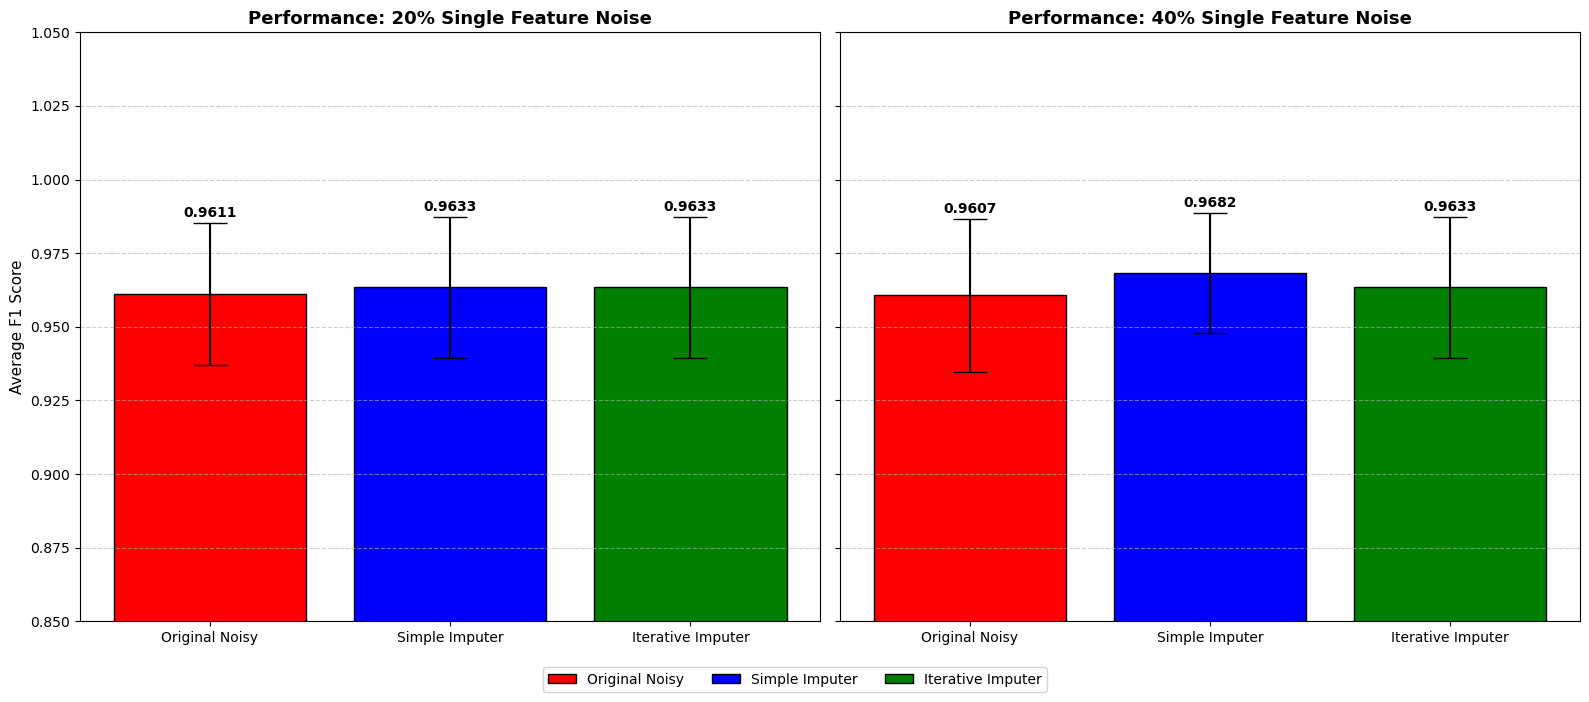

In [54]:
# Plotting Code for Single Feature Noise (20% and 40%) 

# Labels for the x-axis
labels = ['Original Noisy', 'Simple Imputer', 'Iterative Imputer']

# Prepare data for 20% and 40% (extracting from single feature results)
means_20 = [np.mean(single_20_results['singleNoisy_20']), np.mean(single_20_results['singleSimpleImputer_20']), np.mean(single_20_results['singleIterativeImputer_20'])]
stds_20 = [np.std(single_20_results['singleNoisy_20']), np.std(single_20_results['singleSimpleImputer_20']), np.std(single_20_results['singleIterativeImputer_20'])]

means_40 = [np.mean(single_40_results['singleNoisy_40']), np.mean(single_40_results['singleSimpleImputer_40']), np.mean(single_40_results['singleIterativeImputer_40'])]
stds_40 = [np.std(single_40_results['singleNoisy_40']), np.std(single_40_results['singleSimpleImputer_40']), np.std(single_40_results['singleIterativeImputer_40'])]

# Initialize subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
colors = ['red', 'blue', 'green']

# Plot 1: 20% Single Feature Noise
bars1 = ax1.bar(labels, means_20, yerr=stds_20, capsize=12, color=colors, edgecolor='black', label=labels)
ax1.set_title('Performance: 20% Single Feature Noise', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average F1 Score', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Positioning text above the error bars
for i, bar in enumerate(bars1):
    # Calculate the error bar: Mean + Standard Deviation for each imputations
    error_bar = means_20[i] + stds_20[i]
    # text above bar and size of bar
    ax1.text(bar.get_x() + bar.get_width()/2, error_bar + 0.001, 
             f'{means_20[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: 40% Single Feature Noise 
bars2 = ax2.bar(labels, means_40, yerr=stds_40, capsize=12, color=colors, edgecolor='black')
ax2.set_title('Performance: 40% Single Feature Noise', fontsize=13, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Positioning text above the error bars
for i, bar in enumerate(bars2):
    # Calculate the error bar: Mean + Standard Deviation for each imputations
    error_bar = means_40[i] + stds_40[i]
    # text above bar and size of bar
    ax2.text(bar.get_x() + bar.get_width()/2, error_bar + 0.001, 
             f'{means_40[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# Creating a single legend for the entire figure
fig.legend(bars1, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=3)

# Display plot
plt.ylim(0.85, 1.05) 
plt.tight_layout(rect=[0, 0.05, 1, 1]) # Legend at bottom
plt.show()

# Q1 Random Feature Noise Imputations for 20%

In [33]:
# Showing the Dataset with the NaNs (20%)
random_feature_20

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [34]:
# Create a array to store F1 scores for each fold
random_20_results = {
    'randomNoisy_20': [],
    'randomSimpleImputer_20': [],
    'randomIterativeImputer_20': []
}

# Initialize Stratified 5-Fold CV
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Random Feature Noise 20% 5-Fold Results:")

# Tracking each fold for each case for outputing it 
for fold_idx, (train_idx, test_idx) in enumerate(cross_val.split(random_feature_20, y), 1):
    # Splitting the training data and testing data
    X_train, X_test = random_feature_20.iloc[train_idx], random_feature_20.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # convert into 1D
    y_train_flat = y_train.values.flatten()

    # Noisy Original
    # Logistic Regression can't work with NaN so I use .fillna(0) 
    # Default max_iter=100 had convergence error
    clf_noisy = LogisticRegression(max_iter=100)
    clf_noisy.fit(X_train.fillna(0), y_train_flat)
    
    # storing the f1 score that it predicts
    f1_noisy = f1_score(y_test, clf_noisy.predict(X_test.fillna(0)), pos_label='M')
    
    # Add results to the randomNoisy_20 array
    random_20_results['randomNoisy_20'].append(f1_noisy)

    # SimpleImputer
    simple_imp = SimpleImputer() # default parameters
    
    # fit transform train and test seperately
    X_train_simple = simple_imp.fit_transform(X_train)
    X_test_simple = simple_imp.transform(X_test)
    
    # Default max_iter=100 had convergence error 
    clf_simple = LogisticRegression(max_iter=100)
    clf_simple.fit(X_train_simple, y_train_flat)
    
    # storing the f1 score that it predicts
    f1_simple = f1_score(y_test, clf_simple.predict(X_test_simple), pos_label='M')
    
    # Add results to the SimpleImputer_20 array
    random_20_results['randomSimpleImputer_20'].append(f1_simple)

    # IterativeImputer
    # used random state = 42 for consistent and same output each run
    iter_imp = IterativeImputer(random_state=42)
    X_train_iter = iter_imp.fit_transform(X_train)
    X_test_iter = iter_imp.transform(X_test)
    
    # Default max_iter=100 had convergence error 
    clf_iter = LogisticRegression(max_iter=100)
    clf_iter.fit(X_train_iter, y_train_flat)
    
    # storing the f1 score that it predicts
    f1_iter = f1_score(y_test, clf_iter.predict(X_test_iter), pos_label='M')
    
    # Add results to the randomIterativeImputer_20 array
    random_20_results['randomIterativeImputer_20'].append(f1_iter)
    
    # Output the F1 scores for the current fold
    print(f"Fold {fold_idx}: Noisy={f1_noisy:.4f}, Simple={f1_simple:.4f}, Iterative={f1_iter:.4f}")

print("\nPerformance Metrics (Average +/- standard deviation):")

# Calculate and printing the average of f1 scores and standard deviation
for method, scores in random_20_results.items():
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    print(f"{method}: Average F1 Score = {mean_f1:.4f} & Standard Deviation = +/- {std_f1:.4f}")

Random Feature Noise 20% 5-Fold Results:


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 1: Noisy=0.9024, Simple=0.8864, Iterative=0.9195


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 2: Noisy=0.8537, Simple=0.8642, Iterative=0.8889


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 3: Noisy=0.8750, Simple=0.9250, Iterative=0.9268


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 4: Noisy=0.9318, Simple=0.9639, Iterative=0.9524
Fold 5: Noisy=0.9114, Simple=0.9500, Iterative=0.9630

Performance Metrics (Average +/- standard deviation):
randomNoisy_20: Average F1 Score = 0.8949 & Standard Deviation = +/- 0.0275
randomSimpleImputer_20: Average F1 Score = 0.9179 & Standard Deviation = +/- 0.0376
randomIterativeImputer_20: Average F1 Score = 0.9301 & Standard Deviation = +/- 0.0261


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Q1 Random Feature Noise Imputations for 40%

In [35]:
# Showing the Dataset with the NaNs (40%)
random_feature_40

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,NaN,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [36]:
# Create a array to store F1 scores for each fold
random_40_results = {
    'randomNoisy_40': [],
    'randomSimpleImputer_40': [],
    'randomIterativeImputer_40': []
}

# Initialize Stratified 5-Fold CV
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Random Feature Noise 40% 5-Fold Results:")

# Tracking each fold for each case for outputing it 
for fold_idx, (train_idx, test_idx) in enumerate(cross_val.split(random_feature_40, y), 1):
    # Splitting the training data and testing data
    X_train, X_test = random_feature_40.iloc[train_idx], random_feature_40.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # convert into 1D
    y_train_flat = y_train.values.flatten()

    # Noisy Original
    # Logistic Regression can't work with NaN so I use .fillna(0) 
    # Default max_iter=100 had convergence error 
    clf_noisy = LogisticRegression(max_iter=100)
    clf_noisy.fit(X_train.fillna(0), y_train_flat)
    
    # storing the f1 score that it predicts
    f1_noisy = f1_score(y_test, clf_noisy.predict(X_test.fillna(0)), pos_label='M')
    
    # Add results to the randomNoisy_40 array
    random_40_results['randomNoisy_40'].append(f1_noisy)

    # SimpleImputer
    simple_imp = SimpleImputer() # default parameters
    
    # fit transform train and test seperately
    X_train_simple = simple_imp.fit_transform(X_train)
    X_test_simple = simple_imp.transform(X_test)
    
    # Default max_iter=100 had convergence error
    clf_simple = LogisticRegression(max_iter=100)
    clf_simple.fit(X_train_simple, y_train_flat)
    
    # storing the f1 score that it predicts
    f1_simple = f1_score(y_test, clf_simple.predict(X_test_simple), pos_label='M')
    
    # Add results to the SimpleImputer_40 array
    random_40_results['randomSimpleImputer_40'].append(f1_simple)

    # IterativeImputer
    # used random state = 42 for consistent and same output each run
    iter_imp = IterativeImputer(random_state=42)
    X_train_iter = iter_imp.fit_transform(X_train)
    X_test_iter = iter_imp.transform(X_test)
    
    # Default max_iter=100 had convergence error 
    clf_iter = LogisticRegression(max_iter=100)
    clf_iter.fit(X_train_iter, y_train_flat)
    
    # storing the f1 score that it predicts
    f1_iter = f1_score(y_test, clf_iter.predict(X_test_iter), pos_label='M')
    
    # Add results to the randomIterativeImputer_40 array
    random_40_results['randomIterativeImputer_40'].append(f1_iter)
    
    # Output the F1 scores for the current fold
    print(f"Fold {fold_idx}: Noisy={f1_noisy:.4f}, Simple={f1_simple:.4f}, Iterative={f1_iter:.4f}")

print("\nPerformance Metrics (Average +/- standard deviation):")

# Calculate and printing the average of f1 scores and standard deviation
for method, scores in random_40_results.items():
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    print(f"{method}: Average F1 Score = {mean_f1:.4f} & Standard Deviation = +/- {std_f1:.4f}")

Random Feature Noise 40% 5-Fold Results:


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 1: Noisy=0.8941, Simple=0.8989, Iterative=0.9195


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 2: Noisy=0.8608, Simple=0.8608, Iterative=0.8750


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 3: Noisy=0.8395, Simple=0.8605, Iterative=0.9157


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Fold 4: Noisy=0.9157, Simple=0.9535, Iterative=0.9302
Fold 5: Noisy=0.8750, Simple=0.9639, Iterative=0.9500

Performance Metrics (Average +/- standard deviation):
randomNoisy_40: Average F1 Score = 0.8770 & Standard Deviation = +/- 0.0263
randomSimpleImputer_40: Average F1 Score = 0.9075 & Standard Deviation = +/- 0.0442
randomIterativeImputer_40: Average F1 Score = 0.9181 & Standard Deviation = +/- 0.0246


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Q1 Plots for the Random Feature Noise Perfomance 20% vs 40%

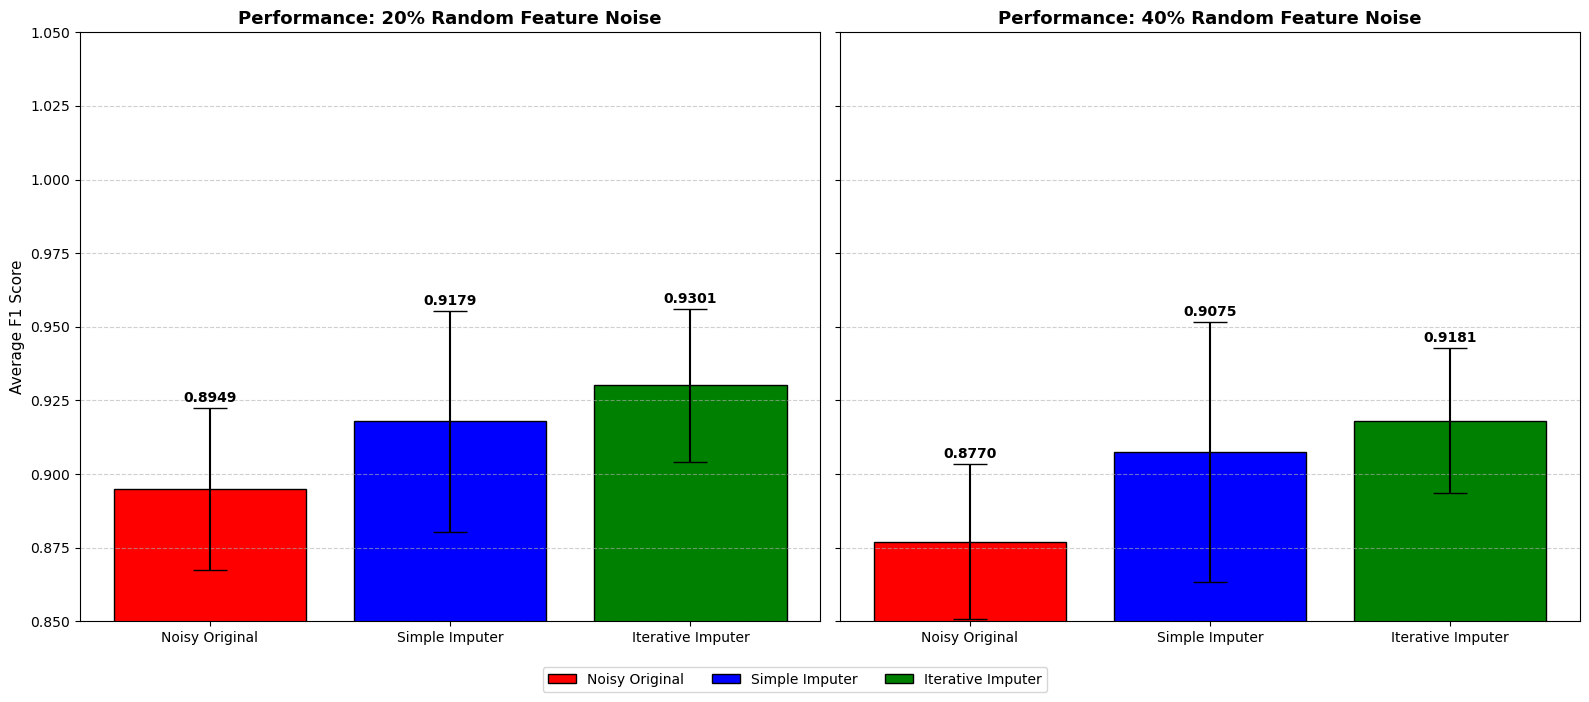

In [37]:
# Plotting Code for Random Feature Noise (20% and 40%) 

# Labels for the x-axis
labels = ['Noisy Original', 'Simple Imputer', 'Iterative Imputer']

# Prepare data for 20% and 40% extracting from the random results array
randomMeans_20 = [np.mean(random_20_results['randomNoisy_20']), np.mean(random_20_results['randomSimpleImputer_20']), np.mean(random_20_results['randomIterativeImputer_20'])]
randomStds_20 = [np.std(random_20_results['randomNoisy_20']), np.std(random_20_results['randomSimpleImputer_20']), np.std(random_20_results['randomIterativeImputer_20'])]

randomMeans_40 = [np.mean(random_40_results['randomNoisy_40']), np.mean(random_40_results['randomSimpleImputer_40']), np.mean(random_40_results['randomIterativeImputer_40'])]
randomStds_40 = [np.std(random_40_results['randomNoisy_40']), np.std(random_40_results['randomSimpleImputer_40']), np.std(random_40_results['randomIterativeImputer_40'])]

# Initialize subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
colors = ['red', 'blue', 'green']

# Plot 1: 20% Random Feature Noise
bars1 = ax1.bar(labels, randomMeans_20, yerr=randomStds_20, capsize=12, color=colors, edgecolor='black', label=labels)
ax1.set_title('Performance: 20% Random Feature Noise', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average F1 Score', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Positioning text above the error bars
for i, bar in enumerate(bars1):
    # Calculate the error bar: Mean + Standard Deviation for each imputations
    error_bar = randomMeans_20[i] + randomStds_20[i]
    # text above bar and size of bar
    ax1.text(bar.get_x() + bar.get_width()/2, error_bar + 0.001, 
             f'{randomMeans_20[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: 40% Random Feature Noise 
bars2 = ax2.bar(labels, randomMeans_40, yerr=randomStds_40, capsize=12, color=colors, edgecolor='black')
ax2.set_title('Performance: 40% Random Feature Noise', fontsize=13, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Positioning text above the error bars
for i, bar in enumerate(bars2):
    # Calculate the error bar: Mean + Standard Deviation for each imputations
    error_bar = randomMeans_40[i] + randomStds_40[i]
    # text above bar and size of bar
    ax2.text(bar.get_x() + bar.get_width()/2, error_bar + 0.001, 
             f'{randomMeans_40[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# Creating a single legend for the entire figure
fig.legend(bars1, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=3)

# Display plot
plt.ylim(0.85, 1.05) 
plt.tight_layout(rect=[0, 0.05, 1, 1]) #Legend at the bottom
plt.show()

# Results Table of the Two Noise Variants Performance Metrics for Q1
#### Average F1 Scores and +/- Standard Deviation for Logistic Regression Classification Predict on "Malignant" class
| Noise Variants | Noise Level | Noisy Original | Simple Imputer | Iterative Imputer |
| --- | --- | --- | --- | --- |
| **Single Feature** (radius1) | 20% | 0.9379 +/- 0.0212 | 0.9375 +/- 0.0266 | 0.9375 +/- 0.0266 |
| **Single Feature** (radius1) | 40% | 0.9374 +/- 0.0221 | 0.9375 +/- 0.0266 | 0.9375 +/- 0.0266 |
| **Random Features** | 20% | 0.9208 +/- 0.0240 |  0.9375 +/- 0.0266 |  0.9375 +/- 0.0266 |
| **Random Features** | 40% | 0.9270 +/- 0.0155 | 0.9301 +/- 0.0290 | 0.9375 +/- 0.0266 |

# Q2 Dimensionality reduction 
We are going to compare how two different dimensionality reduction techniques affect the performance.

- **Singular Value Decomposition:** The Singular Value Decomposition (SVD) is an extremely useful tool from linear algebra that can help us approximate a data matrix (such as the instance-by-feature matrix that represents our data) into a smaller dimension, hence reduce the dimensionality of the data. 

- **Autoencoder:** In certain ways, the autoencoder is the neural network alternative to the SVD, where an encoder network produces an intermediate (latent) representation of that data, and a decoder network transforms the data back to the original space, while ensuring during training that the decoded output is as close to the input as possible. For the purposes of this exercise, your autoencoder should have two hidden layers, with widths equal to  (a) min(d,2*k) (where d is the original dimensionality of your data) and (b) k respectively (and accordingly for the decoder), and with ReLU activation functions.

- **plot:** for k = [2, 5, 10] being the dimensionality of the latent representation, create a figure that shows the performance as a function of k for the two dimensionality reduction techniques and draws as a straight horizontal line the average performance without dimensionality reduction. You may skip adding error-bars on that horizontal line only. 

**DELETE LATER** In this question you should use the SVD (you may use the existing NumPy library) to approximate the data in different ranks. Because we are dealing with supervised learning, given a train/test split, in order to avoid data leakage you should always make sure that you only compute the SVD on the train split and project the test instances to that space, in the same way that the Latent Semantic Analysis paper  does. 


You may use Scikit-learn functionality to train your autoencoder. Similar to the SVD, the autoencoder should only be trained on the train set and only applied to the test set. The output of the encoder will be the new latent representation of the data. 

# Q2 Singular Value Decomposition
- I am using numpy.linalg.svd

- Ref NumPy: https://numpy.org/devdocs/reference/generated/numpy.linalg.svd.html

